In [8]:
import numpy as np


def relative_error(true_value, approximate_value):
    """
    Calculate the relative error between the true value and the approximate value.
    """
    return abs((true_value - approximate_value) / true_value)

true_value = lambda a: (np.exp(a) - np.exp(0)) / a

def crude_montecarlo(N, a):
    """
    Perform crude Monte Carlo integration to estimate the integral of 1/a * exp(x) from 0 to a.
    """
    samples = np.random.uniform(0, a, N)
    integral_estimate = np.mean(np.exp(samples))
    estimate_variance = np.var(samples)
    return integral_estimate, estimate_variance

A = np.linspace(1, 100, 1000)
N = 10000
rel_errors = []
for a in A:

    true_val = true_value(a)
    approx_val = crude_montecarlo(N, a)[0]
    rel_err = relative_error(true_val, approx_val)
    rel_errors.append(rel_err)

a = 2
crude_montecarlo(N,a)

(np.float64(3.213960543360745), np.float64(0.3379610403078905))

I plot the relative error as a function of a.

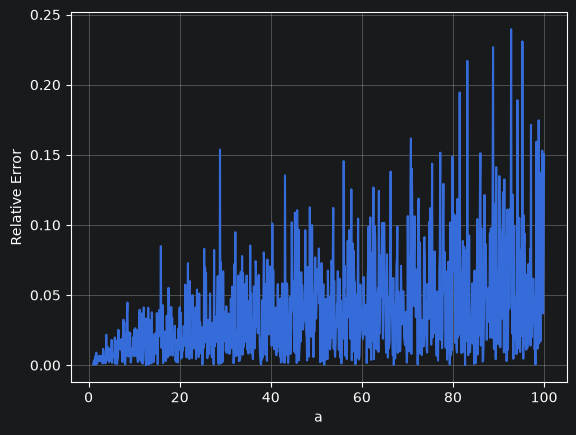

In [9]:
import matplotlib.pyplot as plt
plt.plot(A, rel_errors)
plt.xlabel('a')
plt.ylabel('Relative Error')
plt.grid(True)
plt.show()

We now wish to introduce some control variates for variance reduction. If we recall that
$$e^x \approx 1 + x + a_2x^2 + a_3x^3 + ... $$
for suitable constants $a_2, a_3, ...$, we can use the first few terms of this expansion as control variates. However, for small values of $a$, the first terms will dominate, and for larger values of $a$, the higher order terms will becomes more significant. As such a good choice of control variates will depend on the value of $a$.

Note that the np.cov function computes the covariance matrix of the input array, where each row represents a variable and each column represents an observation. The resulting covariance matrix is symmetric, with the diagonal elements representing the variances of each variable and the off-diagonal elements representing the covariances between pairs of variables.

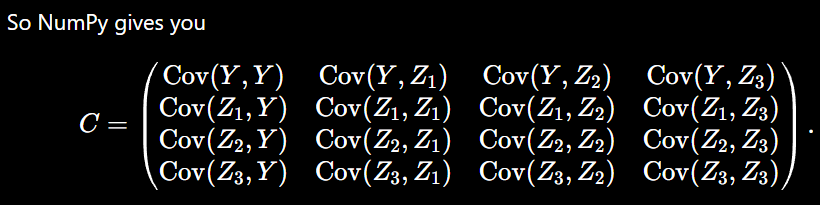

In [10]:
def multiple_control_montecarlo(N, a, exponent_range):
    """
    Perform crude Monte Carlo integration to estimate the integral of 1/a * exp(x) from 0 to a.
    """
    samples = np.random.uniform(0, a, N)
    # Construct controls
    Z = np.vstack([samples**i for i in exponent_range])

    # For a uniform(0,a) we can compute the moments analytically:
    l_h = np.array([a**(i)/(i+1) for i in exponent_range])
    l_h = np.expand_dims(l_h, axis=1)

    # Target variable
    Y = np.exp(samples)

    def compute_optimal_coefficients(Y, Z):
        """
        Compute the optimal coefficients for control variates.
        Y = Target
        Z = Control Variate(s)
        """
        YZ = np.vstack([Y,Z])
        # np.cov, computes the covariance of all each row (variable)
        # S0 we have to extract the according matrices and vectors
        C = np.cov(YZ)
        cov_YZ = C[0, 1:]
        cov_z = C[1:, 1:]
        cov_z_inv = np.linalg.inv(cov_z)

        beta_opt = cov_YZ @ cov_z_inv
        return beta_opt

    # Return vector of size len(exponent_range) = p vector
    beta_opt = compute_optimal_coefficients(Y, Z)

    l_c = np.mean(Y - beta_opt@(Z - l_h))
    l_c_variance = np.var(Y - beta_opt@(Z - l_h))
    return l_c, l_c_variance


multiple_control_montecarlo(N, 2, range(1,4))

(np.float64(3.1944450966642957), np.float64(8.264064210579277e-05))

If we compare the relative errors as a function of a for the crude Monte Carlo and the multiple control variate Monte Carlo, we can see that the multiple control variate Monte Carlo has a significantly lower relative error for all values of a. This demonstrates the effectiveness of using control variates to reduce variance in Monte Carlo simulations.

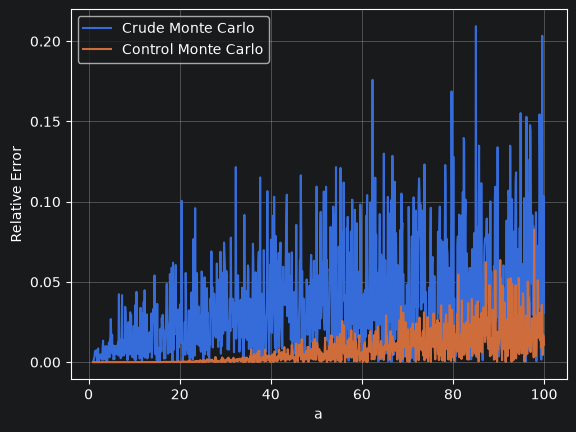

In [17]:
rel_errors = []
for a in A:

    true_val = true_value(a)
    approx_vals = (crude_montecarlo(N, a)[0],
                  multiple_control_montecarlo(N,a, range(1,10))[0])
    rel_err = relative_error(true_val, approx_vals[0]), relative_error(true_val, approx_vals[1])
    rel_errors.append(rel_err)


rel_crude, rel_control = zip(*rel_errors)
plt.plot(A, rel_crude, label='Crude Monte Carlo')
plt.plot(A, rel_control, label='Control Monte Carlo')
plt.xlabel('a')
plt.ylabel('Relative Error')
plt.legend()
plt.grid(True)
plt.show()